# Generate an image using the LDA theta table and PCA

Applied PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Colored the points basd on a metadata feature from the LIB table.(Author)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


## Get Data

In [9]:
directory_path = 'C:/Users/mason/Box/Text As Data Final/Output'
THETA = pd.read_csv(f"{directory_path}/BrandonSanderson_THETA.csv").reset_index(drop=True)
THETA.head()


,title,chapter_id,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14
0,A Memory of Light,0,0.000051,0.000051,0.127560,0.000051,0.464666,0.000051,0.000051,0.000051,0.035079,0.000051,0.000051,0.009553,0.333880,0.000051,0.028807
1,A Memory of Light,1,0.000064,0.000064,0.000064,0.000064,0.524857,0.000064,0.000064,0.005632,0.000064,0.089141,0.000064,0.000064,0.332002,0.000064,0.047731
2,A Memory of Light,2,0.000069,0.000069,0.116256,0.000069,0.371247,0.000069,0.000069,0.000069,0.000069,0.115051,0.000069,0.009970,0.386787,0.000069,0.000069
3,A Memory of Light,3,0.025743,0.025638,0.061436,0.000065,0.315572,0.000065,0.000065,0.000065,0.000065,0.220391,0.000065,0.000065,0.350640,0.000065,0.000065
4,A Memory of Light,4,0.000040,0.000040,0.127590,0.000040,0.531097,0.000040,0.000040,0.000040,0.020126,0.000040,0.070407,0.000040,0.238759,0.000040,0.011660


In [10]:
LIB = pd.read_csv(f"{directory_path}/BrandonSanderson_LIB.csv")
LIB.head()

,title,Author,Date,Length,Total_chapters,Total_paragraphs,File_path
0,A Memory of Light,Robert Jordan & Brandon Sanderson,2013-01-08,279300,48,8694,C:/Users/mason/Box/Text As Data Final/Sanderso...
1,Arcanum Unbounded,Brandon Sanderson,2016-11-22,30328,17,946,C:/Users/mason/Box/Text As Data Final/Sanderso...
2,Elantris,Brandon Sanderson,2005-04-21,199771,66,6372,C:/Users/mason/Box/Text As Data Final/Sanderso...
3,Isles of the Emberdark,Brandon Sanderson,2025-01-01,35349,22,1212,C:/Users/mason/Box/Text As Data Final/Sanderso...
4,Oathbringer,Brandon Sanderson,2017-11-14,117420,34,4002,C:/Users/mason/Box/Text As Data Final/Sanderso...


In [11]:
topic_cols = [c for c in THETA.columns if c.startswith('T') and c[1:].isdigit()]
topic_means = THETA[topic_cols].mean(axis=0)

merged_data = pd.merge(THETA[['title']+ topic_cols], LIB[['title', 'Author']], on='title', how='left')


author_topic_means = merged_data.groupby('Author')[topic_cols].mean()
dominant_topic = author_topic_means.idxmax(axis=0)

pca = PCA(n_components=2)
pca.fit(THETA[topic_cols])

topic_coordinates = pca.components_[:2, :].T

plot_df = pd.DataFrame({
    'Topic': topic_cols,
    'PC0': topic_coordinates[:, 0],
    'PC1': topic_coordinates[:, 1],
    'Mean_Weight': topic_means.values,
    'Dominant_Author': dominant_topic.values
})

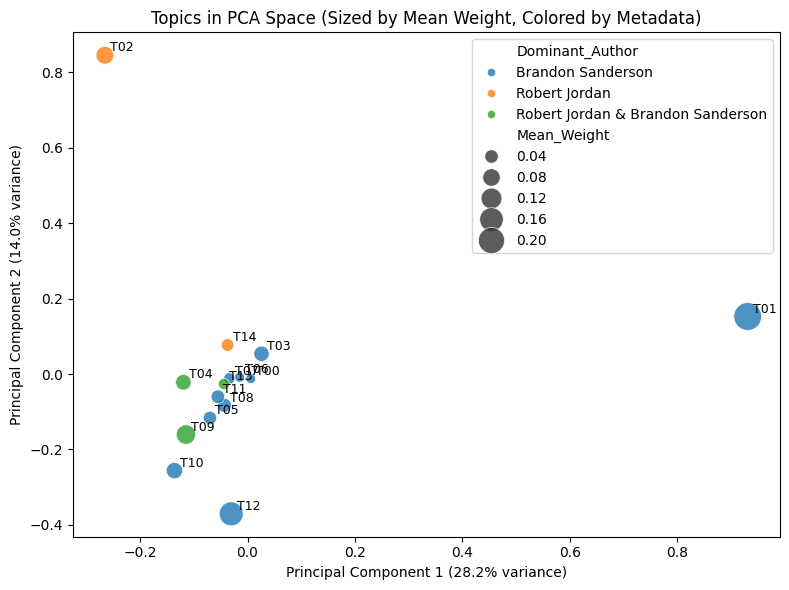

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='PC0',
    y='PC1',
    size='Mean_Weight',
    sizes=(50, 400),
    hue='Dominant_Author',
    palette='tab10',
    alpha=0.8
)

for i, row in plot_df.iterrows():
    plt.text(row['PC0'] + 0.01, row['PC1'] + 0.01, row['Topic'], fontsize=9)

plt.title('Topics in PCA Space (Sized by Mean Weight, Colored by Metadata)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(directory_path + "/LDAwithPCA.png", dpi=300, bbox_inches='tight')

These topic ranked by PCA over Mean Weight show a clear authorship divide between the 2 Author Brandon Sanderson and Robert Jordan. The first principle componenet is dominated by T01 which is exclusicely Brandon Sanderson. The second priniple component is dominated T02 by Robert Jordan. The neat thing is that on project they both worked on we see a clustering around both principle components.